Text(0.5, 1.0, 'Sentinel NN Architecture')

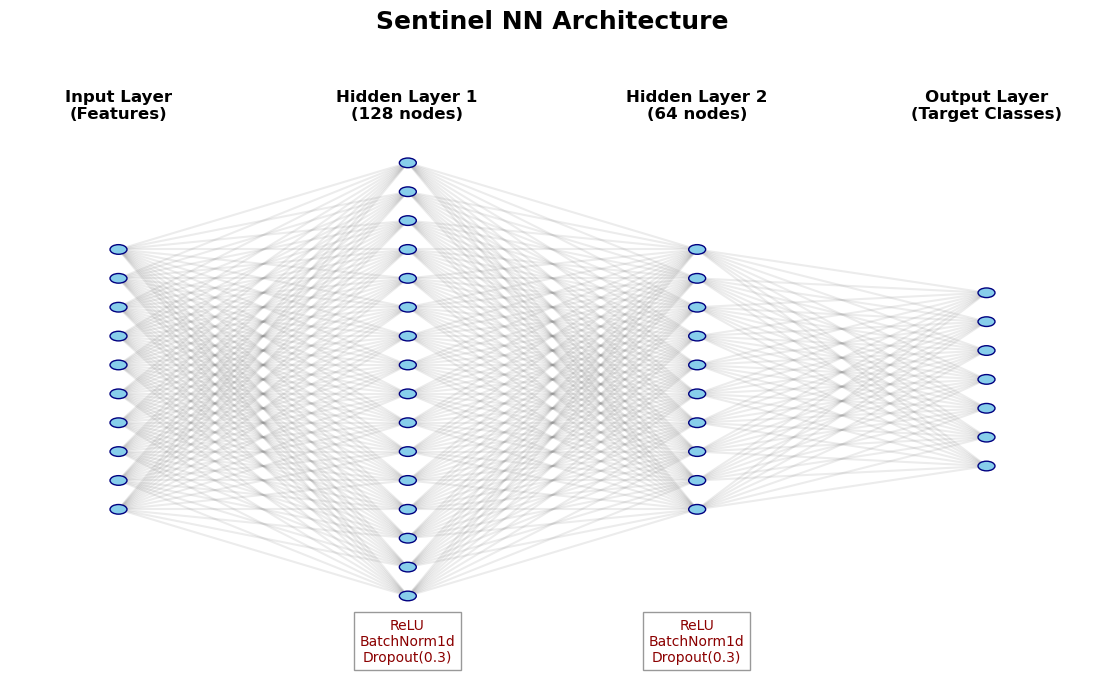

In [ ]:
import matplotlib.pyplot as plt
import os

def draw_neural_net(ax, left, right, bottom, top, layer_sizes):
    """
    Draw a neural network cartoon using matplotlib.
    """
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)
    
    # Nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for m in range(layer_size):
            circle = plt.Circle((n*h_spacing + left, layer_top - m*v_spacing), v_spacing/6.,
                                color='skyblue', ec='navy', zorder=4)
            ax.add_artist(circle)
            
    # Edges
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n + 1)*h_spacing + left],
                                  [layer_top_a - m*v_spacing, layer_top_b - o*v_spacing], c='gray', alpha=0.15, zorder=1)
                ax.add_artist(line)

fig = plt.figure(figsize=(14, 8))
ax = fig.gca()
ax.axis('off')

# Scaled down representation for visual clarity
layer_sizes = [10, 16, 10, 7]
draw_neural_net(ax, .1, .9, .1, .85, layer_sizes)

# Add Labels
plt.text(0.1, 0.92, "Input Layer\n(Features)", ha='center', va='center', fontsize=12, fontweight='bold')
plt.text(0.366, 0.92, "Hidden Layer 1\n(128 nodes)", ha='center', va='center', fontsize=12, fontweight='bold')
plt.text(0.633, 0.92, "Hidden Layer 2\n(64 nodes)", ha='center', va='center', fontsize=12, fontweight='bold')
plt.text(0.9, 0.92, "Output Layer\n(Target Classes)", ha='center', va='center', fontsize=12, fontweight='bold')

plt.text(0.366, 0.05, "ReLU\nBatchNorm1d\nDropout(0.3)", ha='center', va='center', fontsize=10, color='darkred', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.text(0.633, 0.05, "ReLU\nBatchNorm1d\nDropout(0.3)", ha='center', va='center', fontsize=10, color='darkred', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title("Sentinel NN Architecture", fontsize=18, fontweight='bold', pad=20)

